<p> <center><img src="https://datascientest.fr/train/assets/logo_datascientest.png" style="height:200px"></center> </p>

<hr style="border-width:2px;border-color:#ff6745">
<center><h1> Analyse et prédiction de la variabilité de la production solaire à partir de données ouvertes de la région PACA </h1></center>
<center><h2> Collecte des données de production d'énergie solaire </h2></center>
<hr style="border-width:2px;border-color:#ff6745">


La variable dont on souhaite étudier la variabilité est le **Taux de CHarge de la production solaire** (TCH solaire). On peut trouver cette variable dans les données mises à disposition par RTE dans un dataset appelé **éCO2mix** (distribué par Ordré Opendata Réseaux-Energies sous licence Ouverte 2.0 (Etalab) https://www.etalab.gouv.fr/wp-content/uploads/2017/04/ETALAB-Licence-Ouverte-v2.0.pdf d'après https://odre.opendatasoft.com/explore/dataset/eco2mix-regional-cons-def/information/?disjunctive.nature&disjunctive.libelle_region).

Si cette base de données nous fourni une variable nous permettant de calculer notre variable cible, elle ne comprend **aucune donnée météo ou astronomique** permettant d'expliquer la production d'énergie solaire : nous savons donc dès le départ que nous devrons **compléter** cette base par d'autres données.

Or la base éCO2mix se présente sous forme d'une série temporelle : on pourra donc partir de la **variable temporelle** pour aggréger de nouvelles données par la suite.

Concrètement, à cette étape de la collecte, il nous faut :

* **Récupérer** les données d'éCO2mix.
* Ne **conserver** que les observations où notre **base de calcul** (TCH solaire) pour la variable cible  est présente.
* **Abandonner** les données ne concernant pas l'énergie solaire (la base éCO2mix contient des données concernant d'autres types d'énergies).
* Vérifier le **fuseau horaire** de la variable temporelle et le convertir en **UTC** si besoin, de manière à pouvoir aggréger facilement des données d'autres datasets.


# I - Acquisition des données brutes


On importe les librairies dont on va avoir besoin pour manipuler nos jeux de données :

In [2]:
# Gestion des chemins
from pathlib import Path

# Importer des librairies usuelles pour traiter des datasets
import pandas as pd
import numpy as np

# Importer une librairie pour traiter des fichiers zip
from zipfile import ZipFile

On peut trouver les données brutes sur le site Internet de **RTE** (https://www.rte-france.com/donnees-publications/eco2mix-donnees-temps-reel/telecharger-indicateurs).

Sur ce site, on dispose de jeux de données concernant la **région PACA** pour les années **2013 à 2025** incluses (ainsi que janvier 2026), sous forme d'archives comprimées, à raison d'**une archive par année**.

On a préalablement téléchargé ces données et on les a placées dans un répertoire de travail dont on stocke le chemin dans une variable `chemin_datasets`.

In [3]:
# Répertoire des données d'éCO2mix téléchargées
input_path = Path('../../data/local_data/input/')

# Répertoire où seront stockés les résultats
temp_path = Path('../../data/local_data/temp/')

Pour consulter nos datasets, nous devons préalablement lister les noms des archives puis les décompresser.

In [4]:
# Construire une liste des noms des archives à traiter, sans l'extension

## Base des noms des fichiers de production
file_base_name = 'eCO2mix_RTE_PACA_Annuel-Definitif_'
last_file_base_name = 'eCO2mix_RTE_PACA_En-cours-Consolide' # concerne l'année 2025 (et janvier 2026)

## Construction de la liste des bases de noms de fichers
annees_dispos = [a for a in range(2013, 2025)]
file_list = []
for annee in annees_dispos:
    file_list.append(file_base_name + str(annee))

file_list.append(last_file_base_name)

print(file_list)


# Décompresser les archives

## Parcourir la liste des archives
for f in file_list :
    # Extraire chaque archive
    with ZipFile(input_path / (f + '.zip'), 'r') as zip_file :
        zip_file.printdir()
        zip_file.extractall(temp_path)

## Les archives décompressées contiennent des fichiers xls : on met à jour file_list en conséquence
file_list = [temp_path / (f + '.xls') for f in file_list]

['eCO2mix_RTE_PACA_Annuel-Definitif_2013', 'eCO2mix_RTE_PACA_Annuel-Definitif_2014', 'eCO2mix_RTE_PACA_Annuel-Definitif_2015', 'eCO2mix_RTE_PACA_Annuel-Definitif_2016', 'eCO2mix_RTE_PACA_Annuel-Definitif_2017', 'eCO2mix_RTE_PACA_Annuel-Definitif_2018', 'eCO2mix_RTE_PACA_Annuel-Definitif_2019', 'eCO2mix_RTE_PACA_Annuel-Definitif_2020', 'eCO2mix_RTE_PACA_Annuel-Definitif_2021', 'eCO2mix_RTE_PACA_Annuel-Definitif_2022', 'eCO2mix_RTE_PACA_Annuel-Definitif_2023', 'eCO2mix_RTE_PACA_Annuel-Definitif_2024', 'eCO2mix_RTE_PACA_En-cours-Consolide']
File Name                                             Modified             Size
eCO2mix_RTE_PACA_Annuel-Definitif_2013.xls     2021-10-12 20:50:08      2215401
File Name                                             Modified             Size
eCO2mix_RTE_PACA_Annuel-Definitif_2014.xls     2021-10-12 20:50:30      2213552
File Name                                             Modified             Size
eCO2mix_RTE_PACA_Annuel-Definitif_2015.xls     2021-10-1

# II - Première exploration des données éCO2mix

La décompression des archives nous a permis d'obtenir des datasets dans un format *.xls*. Cependant, après examen, ces datasets se révèlent être en fait au format *.csv*, encodés en *latin-1*.

On va maintenant commencer à explorer nos jeux de données et en particulier vérifier la **présence** de notre **base de calcul** (TCH Solaire) pour la **variable cible** (variabilité de la production d'énergie solaire).

In [5]:
# Observer les premières lignes du dataset le plus ancien (correspond à l'année 2013) :
print("\nJeu de données 2013 :")

## Lire le jeu de données
df = pd.read_csv(file_list[0], sep='\t', encoding='latin_1')

## Afficher les premières lignes
display(df.head())

## Afficher la taille du dataset
print(f"Nombre de colonnes du jeu de données 2013 : {df.shape[1]}.")


# Observer les premières lignes du dataset le plus récent (correspond à l'année 2025) :
print("\nJeu de données 2025 :")

## Lire le jeu de données
### Malgré son extension, le fichier xls est en fait un fichier csv encodé en 'iso_8859-1' ce qui correspond au 'latin_1'
df = pd.read_csv(file_list[-1], sep='\t', encoding='latin_1')

## Afficher les premières lignes
display(df.head())

## Afficher la taille du dataset
print(f"Nombre de colonnes du jeu de données 2025 : {df.shape[1]}.")



Jeu de données 2013 :


,Périmètre,Nature,Date,Heures,Consommation,Thermique,Nucléaire,Eolien,Solaire,Hydraulique,Pompage,Bioénergies,Ech. physiques,Unnamed: 13
0,PACA,Données définitives,2013-01-01,00:00,ND,ND,ND,ND,ND,ND,ND,ND,ND,NaN
1,PACA,Données définitives,2013-01-01,00:15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PACA,Données définitives,2013-01-01,00:30,5570,537,-,12,0,1412,0,58,3548,NaN
3,PACA,Données définitives,2013-01-01,00:45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PACA,Données définitives,2013-01-01,01:00,5698,315,-,14,0,1371,0,58,3938,NaN


Nombre de colonnes du jeu de données 2013 : 14.

Jeu de données 2025 :


,Périmètre,Nature,Date,Heures,Consommation,Thermique,Nucléaire,Eolien,Solaire,Hydraulique,...,TCH Nucléaire (%),TCO Eolien (%),TCH Eolien (%),TCO Solaire (%),TCH Solaire (%),TCO Hydraulique (%),TCH Hydraulique (%),TCO Bioénergies (%),TCH Bioénergies (%),Unnamed: 29
0,PACA,Données consolidées,2025-01-01,00:00,5751.0,676.0,0.0,0.0,1.0,574.0,...,ND,0.0,0.0,0.02,0.04,9.98,17.77,2.30,43.00,NaN
1,PACA,Données consolidées,2025-01-01,00:15,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PACA,Données consolidées,2025-01-01,00:30,5695.0,494.0,0.0,0.0,0.0,727.0,...,ND,0.0,0.0,0.00,0.00,12.77,22.51,2.30,42.67,NaN
3,PACA,Données consolidées,2025-01-01,00:45,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PACA,Données consolidées,2025-01-01,01:00,5492.0,354.0,0.0,0.0,0.0,733.0,...,ND,0.0,0.0,0.00,0.00,13.35,22.69,2.31,41.37,NaN


Nombre de colonnes du jeu de données 2025 : 30.


En comparant quelques lignes des **premier et dernier datasets**, on remarque que **le nombre de colonnes est différent** (14 colonnes en 2013 contre 30 en 2024).

Les *variables disponibles* ne sont *pas les mêmes d'une année à l'autre*.

Par ailleurs, **l'année 2013 ne comporte pas** la variable `TCH Solaire (%)` et ne nous permet pas de calculer **notre variable cible**.


# III - Sélection des datasets contenant la variable TCH Solaire

Pour notre projet, nous avons besoin de données où la variable `TCH Solaire (%)` est présente.

Nous allons chercher les datasets disponibles qui la comporte.

In [6]:
# Chercher la présence de la variable 'TCH Solaire (%)'

year = 2013 # Sert  à afficher l'année en cours de traitement
var_base_cible = 'TCH Solaire (%)' # Nom de la variable nécessaire au calcul de la variable cible
presence_var_cible = []

# On parcours les datasets
for f in file_list :

    # Lire le jeu de données
    # Malgré son extension, le fichier xls est en fait un fichier csv encodé en 'iso_8859-1' ce qui correspond au 'latin_1'
    df = pd.read_csv(f, sep='\t', encoding='latin_1')

    # On affiche des informations basiques sur le dataset qu'on vient d'extraire
    print(year, ":") # L'année correspondant au dataset en cours de traitement
    print(f"\tTaille du dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes.") # les dimensions du dataset
    presence_var_cible.append(var_base_cible in df.columns)
    print("\tBase de la cible présente :", presence_var_cible[-1], '\n') # la variable est-elle présente dans le dataset

    year += 1


2013 :
	Taille du dataset : 35041 lignes x 14 colonnes.
	Base de la cible présente : False 

2014 :
	Taille du dataset : 35041 lignes x 14 colonnes.
	Base de la cible présente : False 

2015 :
	Taille du dataset : 35041 lignes x 14 colonnes.
	Base de la cible présente : False 

2016 :
	Taille du dataset : 35137 lignes x 14 colonnes.
	Base de la cible présente : False 

2017 :
	Taille du dataset : 35041 lignes x 14 colonnes.
	Base de la cible présente : False 

2018 :
	Taille du dataset : 35041 lignes x 14 colonnes.
	Base de la cible présente : False 

2019 :
	Taille du dataset : 35041 lignes x 14 colonnes.
	Base de la cible présente : False 

2020 :
	Taille du dataset : 35137 lignes x 66 colonnes.
	Base de la cible présente : True 



/tmp/ipykernel_4569/1144132110.py:12: DtypeWarning: Columns (12,13,14,15,17,26,29,38,44,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep='\t', encoding='latin_1')


2021 :
	Taille du dataset : 35041 lignes x 68 colonnes.
	Base de la cible présente : True 

2022 :
	Taille du dataset : 35041 lignes x 68 colonnes.
	Base de la cible présente : True 

2023 :
	Taille du dataset : 35041 lignes x 68 colonnes.
	Base de la cible présente : True 

2024 :
	Taille du dataset : 35137 lignes x 68 colonnes.
	Base de la cible présente : True 

2025 :
	Taille du dataset : 38017 lignes x 30 colonnes.
	Base de la cible présente : True 



Seules les années **2020 à 2025** incluses comprennent la variable `TCH Solaire (%)` : les datasets que nous décidons de conserver sont ceux correspondants à ces années.

# IV - Variables communes aux datasets retenus

Nos souhaitons n'avoir qu'un **unique dataset** comprenant l'ensemble des données de **2020 à 2025** inclus.

Or, nous avons vu que les datasets de différentes années peuvent avoir des **variables différentes** : nous avons besoin de lister les **variables communes** à tous les datasets.

Pour cela, nous allons **lister les variables** présentes dans les datasets, puis prendre les variables d'un des datasets et regarder si elles sont présentes dans les autres datasets. On ne conservera que celles **présentes dans tous les datasets**.

In [7]:
# Stocker les DataFrames dans la variable dataset_list
dataset_list = []
for f, present in zip(file_list, presence_var_cible):
    if present :
        df = pd.read_csv(f, sep='\t', encoding='latin_1')
        dataset_list.append(df)

    
# Etablir la liste de toutes les colonnes des datasets retenus
liste_colonnes = []

## Déclarer puis initialiser la liste des colonnes des datasets en parcourant ces derniers
for df in dataset_list :
    liste_colonnes.append(df.columns)


# Etablir la liste des colonnes présentes dans tous les datasets retenus
variables_retenues = []

## On part des colonnes du premier dataset
for col in liste_colonnes[0]:
    ### La variable col_in_all vaut True si la colonne est présente dans tous les datasets, False sinon
    col_in_all = True # Par défaut on considère que la colonne actuelle est dans les autres datasets

    ### On parcourt les colonnes des autres datasets
    for cols in liste_colonnes[1:] :
        if col not in cols : # Si la colonne courante n'est pas dans le dataset courant
            col_in_all = False # On met à jour col_in_all

    ### Si la colonne est bien présente dans tous les datasets, on l'ajoute à la variables_retenues
    if col_in_all:
        variables_retenues.append(col)


# On affiche la taille et le contenu de la liste finale
print("\nTaille de la liste de variables retenues :", len(variables_retenues))
print("Variables retenues :", variables_retenues)

/tmp/ipykernel_4569/608548652.py:5: DtypeWarning: Columns (12,13,14,15,17,26,29,38,44,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep='\t', encoding='latin_1')



Taille de la liste de variables retenues : 27
Variables retenues : ['Périmètre', 'Nature', 'Date', 'Heures', 'Consommation', 'Thermique', 'Nucléaire', 'Eolien', 'Solaire', 'Hydraulique', 'Pompage', 'Bioénergies', 'Ech. physiques', 'Stockage batterie', 'Déstockage batterie', 'TCO Thermique (%)', 'TCH Thermique (%)', 'TCO Nucléaire (%)', 'TCH Nucléaire (%)', 'TCO Eolien (%)', 'TCH Eolien (%)', 'TCO Solaire (%)', 'TCH Solaire (%)', 'TCO Hydraulique (%)', 'TCH Hydraulique (%)', 'TCO Bioénergies (%)', 'TCH Bioénergies (%)']


Nous avons maintenant la **liste des variables communes aux datasets comprenant la variable permettant de calculer la variable cible**.

On remarque cependant dans cette liste les variables **ne concernent pas** uniquement la **production d'énergie solaire**, mais également la production d'énergie thermique, nucléaire, éolienne, ...

Ces variables risquent de perturber notre futur modèle qui se concentre uniquement sur l'énergie solaire : nous décidons de les **abandonner**.

In [8]:
# On supprime de la liste les colonnes dont on sait qu'elles ne concernent pas l'énergie solaire
variables_retenues.remove('Périmètre')
variables_retenues.remove('Nature')
variables_retenues.remove('Stockage batterie')
variables_retenues.remove('Déstockage batterie')
variables_retenues.remove('Ech. physiques')
variables_retenues.remove('Thermique')
variables_retenues.remove('Nucléaire')
variables_retenues.remove('Eolien')
variables_retenues.remove('Hydraulique')
variables_retenues.remove('Pompage')
variables_retenues.remove('Bioénergies')
variables_retenues.remove('TCO Thermique (%)')
variables_retenues.remove('TCH Thermique (%)')
variables_retenues.remove('TCO Nucléaire (%)')
variables_retenues.remove('TCH Nucléaire (%)')
variables_retenues.remove('TCO Eolien (%)')
variables_retenues.remove('TCH Eolien (%)')
variables_retenues.remove('TCO Hydraulique (%)')
variables_retenues.remove('TCH Hydraulique (%)')
variables_retenues.remove('TCO Bioénergies (%)')
variables_retenues.remove('TCH Bioénergies (%)')

# On affiche les informations et le contenu de la liste finale
print("Taille de la liste de variables retenues :", len(variables_retenues))
print("Variables retenues :", variables_retenues)

Taille de la liste de variables retenues : 6
Variables retenues : ['Date', 'Heures', 'Consommation', 'Solaire', 'TCO Solaire (%)', 'TCH Solaire (%)']


# V - Concaténation des datasets

Maintenant que nous disposons d'une liste de variables communes qui semble pertinente à ce stade, nous pouvons **regrouper les différents datasets en un seul** dataset `df_rte` pour faciliter la suite de l'étude.

In [9]:
# Concaténation des datasets
# On affiche le nombre de lignes total qu'on est supposé obtenir
total_1 = 0
for df in dataset_list :
    total_1 += df.shape[0]
print("Nombre total de lignes avant concaténation :", total_1)

# On concatène sur les colonnes retenues
df_rte = pd.concat([df[variables_retenues] for df in dataset_list], axis=0)

# On affiche le nombre de lignes obtenu
print(f"Le dataset concaténé obtenu présente {df_rte.shape[0]} lignes et {df_rte.shape[1]} colonnes.") # OK

Nombre total de lignes avant concaténation : 213414
Le dataset concaténé obtenu présente 213414 lignes et 6 colonnes.


# VI - Elimination des observations ne comprenant pas la variable TCH Solaire

Faisons maintenant un premier examen de notre nouveau jeu de données.

In [10]:
display(df_rte.head(10))
display(df_rte.describe())
df_rte.info()

,Date,Heures,Consommation,Solaire,TCO Solaire (%),TCH Solaire (%)
0,2020-01-01,00:00,6123.0,0.0,0.0,0.0
1,2020-01-01,00:15,NaN,NaN,NaN,NaN
2,2020-01-01,00:30,5907.0,0.0,0.0,0.0
3,2020-01-01,00:45,NaN,NaN,NaN,NaN
4,2020-01-01,01:00,5724.0,0.0,0.0,0.0
5,2020-01-01,01:15,NaN,NaN,NaN,NaN
6,2020-01-01,01:30,5749.0,0.0,0.0,0.0
7,2020-01-01,01:45,NaN,NaN,NaN,NaN
8,2020-01-01,02:00,5700.0,0.0,0.0,0.0
9,2020-01-01,02:15,NaN,NaN,NaN,NaN


,Consommation,Solaire,TCO Solaire (%),TCH Solaire (%)
count,106704.000000,106704.000000,106704.000000,106704.000000
mean,4490.246767,318.172515,7.037158,16.463376
std,849.073845,466.273232,10.368153,23.489454
min,2620.000000,0.000000,0.000000,0.000000
25%,3859.750000,0.000000,0.000000,0.000000
50%,4388.000000,3.000000,0.080000,0.180000
75%,5062.000000,581.000000,12.680000,31.422500
max,8044.000000,2108.000000,51.490000,91.350000


<class 'pandas.core.frame.DataFrame'>
Index: 213414 entries, 0 to 38016
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date             213408 non-null  object 
 1   Heures           213408 non-null  object 
 2   Consommation     106704 non-null  float64
 3   Solaire          106704 non-null  float64
 4   TCO Solaire (%)  106704 non-null  float64
 5   TCH Solaire (%)  106704 non-null  float64
dtypes: float64(4), object(2)
memory usage: 11.4+ MB


RTE indique dans les spécifications du jeu de données **éCO2mix** que ce dernier a une résolution temporelle de 15 minutes. On remarque cependant rapidement que les données d'une ligne sur deux des datasets ne présente ni donnée de production ni donnée de consommation : la **résolution temporelle** semble en réalité être de **30 minutes**.

En particulier *une ligne sur deux ne contient pas la variable* `TCH Solaire (%)`.

Or nous avons besoin de cette variable pour la construction de nos futurs modèles : nous **supprimons** donc les observations qui ne la comprennent pas.

In [11]:
# On supprime les lignes où notre variable TCH Solaire est manquante
var_base_cible = 'TCH Solaire (%)'
df_rte = df_rte.dropna(subset=[var_base_cible])

On vérifie s'il reste des valeurs manquantes :

In [12]:
print(df_rte.isna().sum())

Date               0
Heures             0
Consommation       0
Solaire            0
TCO Solaire (%)    0
TCH Solaire (%)    0
dtype: int64


Il ne reste **aucune valeur manquante** après l'élimination des observations ne comprenant pas la variable `TCH Solaire (%)`.

# VII - Fuseau horaire

Les **spécifications du jeu de données** éCO2mix décrivant les variables présentes dans ce jeu de données **ne précisent pas le fuseau horaire** auquel les mesures ont été réalisées.

Comme RTE est une entreprise Française et qu'on s'intéresse à la région PACA, on fait l'hypothèse de l'utilisation du **fuseau horaire de France métropolitaine**.

Afin de vérifier cette hypothèse, on va regarder si on observe un passage heure d'été - heure d'hiver grâce aux données de production d'énergie solaire.

Comment se comporte la production entre deux dates où on sait qu'il y a changement d'horaire pour ce fuseau ? **Observe-t-on un décalage horaire dans la production** entre le jour avant et le jour suivant le changement d'heure ?

 - Si oui : le fuseau horaire est bien celui de France métropolitaine ;
 - Si non : le fuseau horaire est peut être le fuseau UTC (dans ce cas un courriel de demande de renseignements aurès de RTE pourrait permettre d'en être sûr).

Comme les datasets n'avaient initialement pas tous le même nombre de variables, on ne sait pas s'ils ont tous été construits avec le même fuseau horaire donc *on vérifie pour les créneaux de changement d'heure de 2020 à 2026*.

Les changements d'heure en France métropolitaine ont eu lieu :
 - En 2020 : entre les 28-29 mars et 24-25 octobre ;
 - En 2021 : entre les 27-28 mars et 30-31 octobre ;
 - En 2022 : entre les 26-27 mars et 29-30 octobre ;
 - En 2023 : entre les 25-26 mars et 28-29 octobre ;
 - En 2024 : entre les 30-31 mars et 26-27 octobre ;
 - En 2025 : entre les 29-30 mars et 25-26 octobre ;
 - En 2026 : entre les 28-29 mars et 24-25 octobre.

In [13]:
# On importe une librairie de Datavizualisation
import matplotlib.pyplot as plt
%matplotlib inline

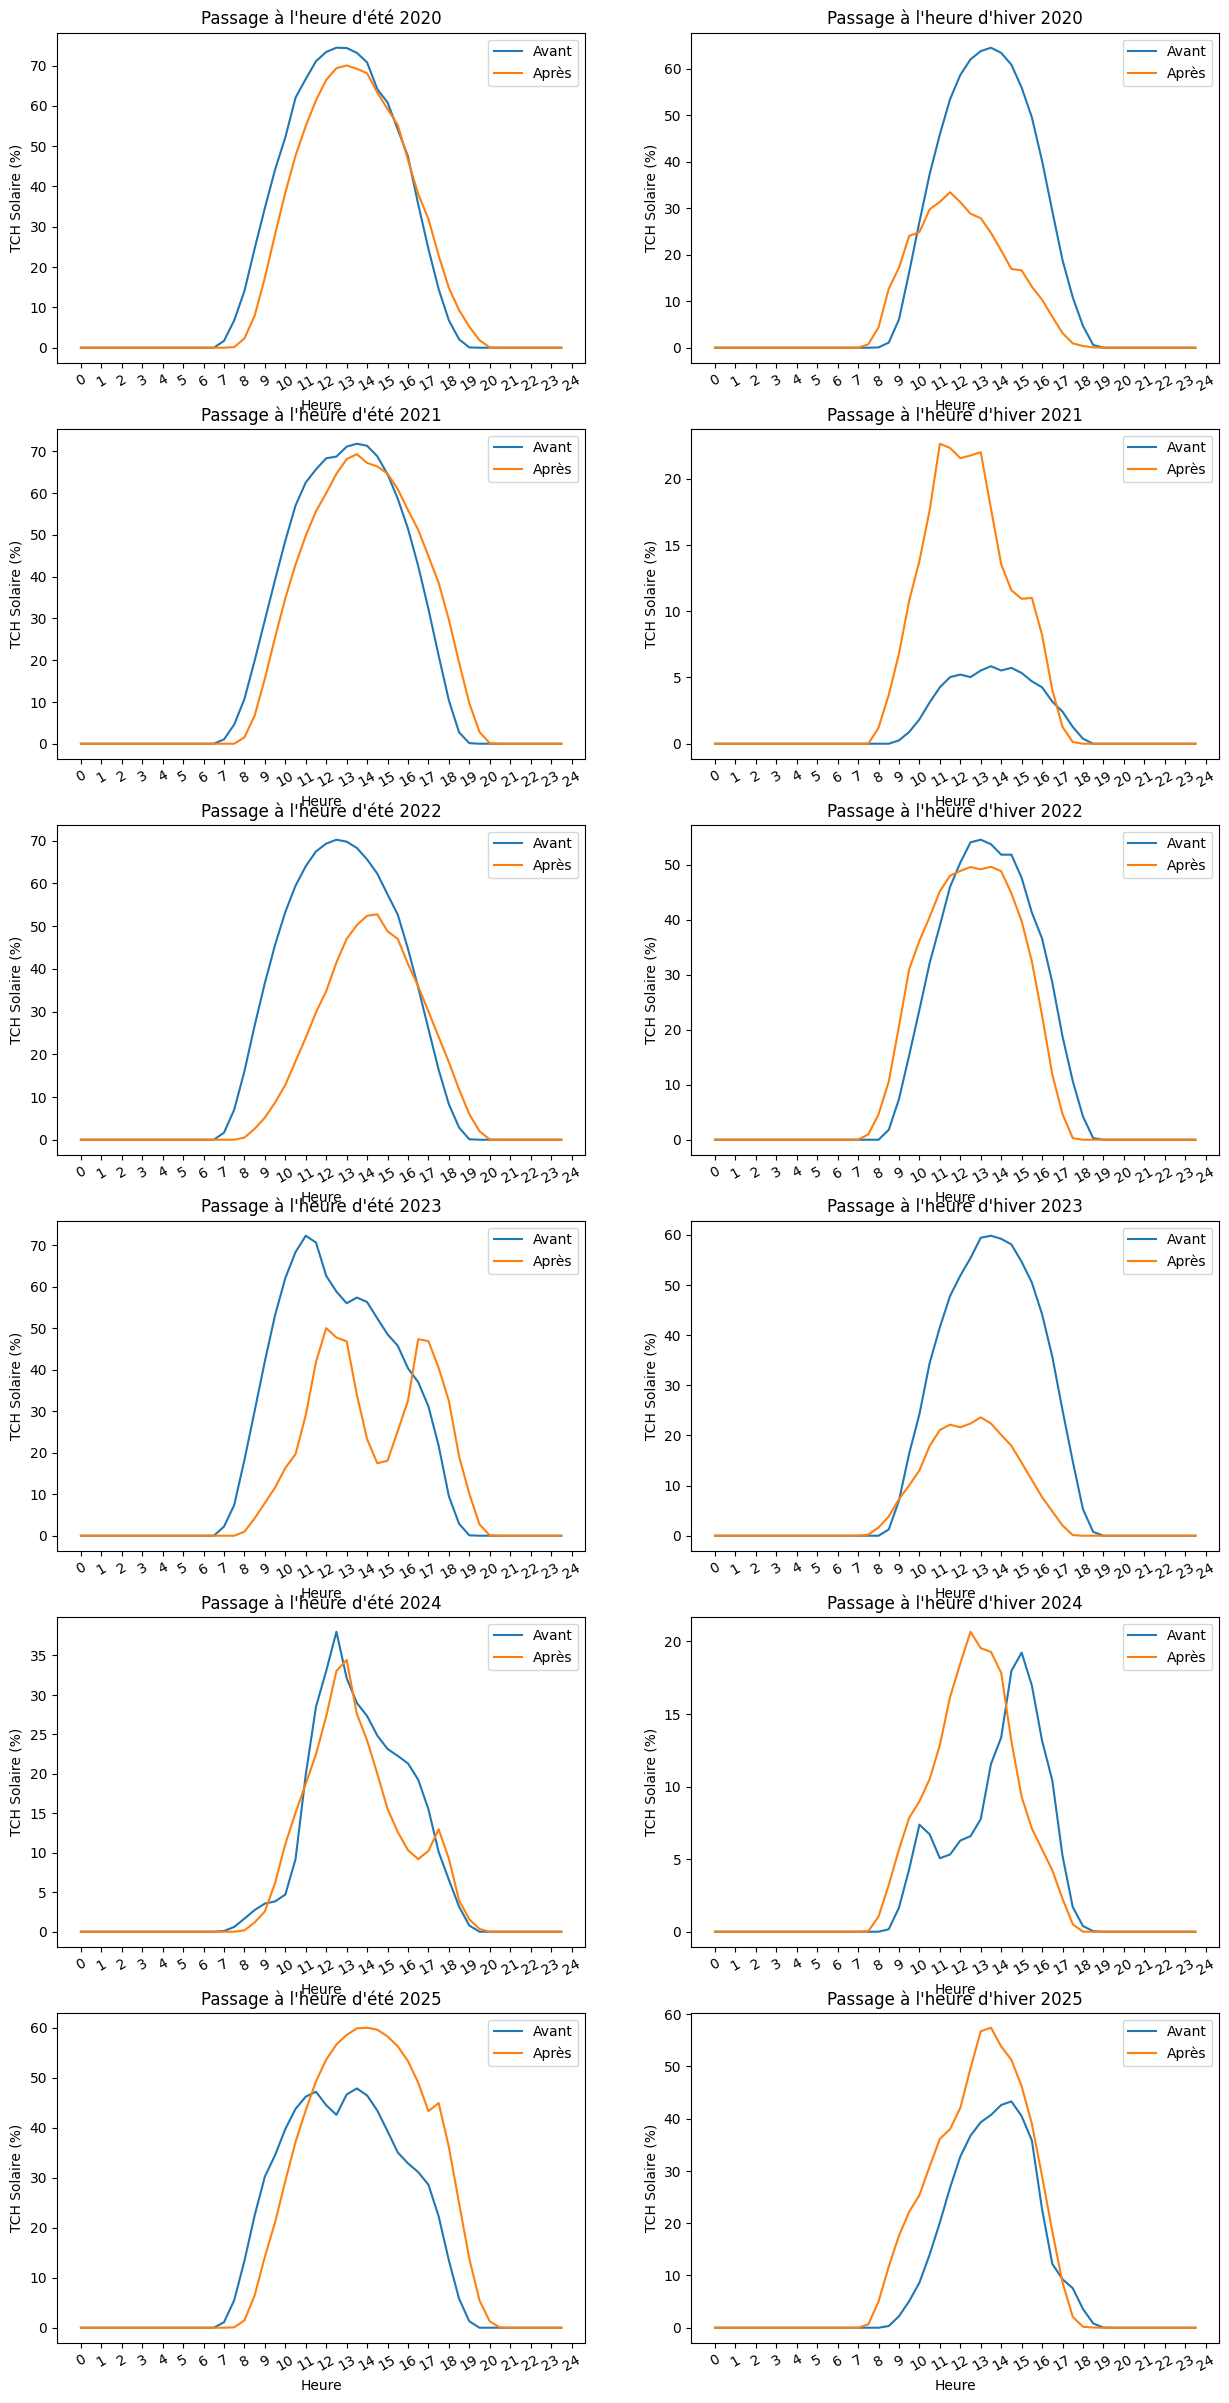

In [14]:
# Extraire les variables pertinentes (date, heure et TCH Solaire)
df = df_rte[['Date', 'Heures', var_base_cible]]

# Lister les jours avant et après les changements d'heure pour le fuseau France métropolitaine
## Jours avant les changements d'heure d'été
ete_av = ['2020-03-28', '2021-03-27', '2022-03-26', '2023-03-25', '2024-03-30', '2025-03-29', '2026-03-28']
## Jours après les changements d'heure d'été
ete_ap = ['2020-03-29', '2021-03-28', '2022-03-27', '2023-03-26', '2024-03-31', '2025-03-30', '2026-03-29']
## Jours avant les changements d'heure d'hiver
hiv_av = ['2020-10-24', '2021-10-30', '2022-10-29', '2023-10-28', '2024-10-26', '2025-10-25', '2026-10-24']
## Jours après les changements d'heure d'hiver
hiv_ap = ['2020-10-25', '2021-10-31', '2022-10-30', '2023-10-29', '2024-10-27', '2025-10-26', '2026-10-25']

# Redimensionner la figure (on va afficher une ligne par année et une colonne par changement d'heure)
plt.figure(figsize=(15,30))

# Pour chaque année
nb_annees = 6
for i in range(nb_annees):
    # On affiche la production d'énergie solaire avant et après le passage à l'heure d'été
    plt.subplot(nb_annees, 2, i*2+1)
    plt.plot(df[df['Date'] == ete_av[i]].Heures, df[df['Date'] == ete_av[i]][var_base_cible], label='Avant')
    plt.plot(df[df['Date'] == ete_ap[i]].Heures, df[df['Date'] == ete_ap[i]][var_base_cible], label='Après')
    plt.xlabel('Heure')
    plt.ylabel(var_base_cible)
    # On nettoie les ticks sur l'axe des x car sinon on ne peut rien lire
    # On n'affiche que les heures
    plt.xticks(
        [2*k for k in range(0, 25)],
        [str(k) for k in range(25)],
        rotation=30)
    plt.title("Passage à l'heure d'été "+str(2020+i))
    plt.legend()
    
    # On affiche la production d'énergie solaire avant et après le passage à l'heure d'hiver
    plt.subplot(nb_annees, 2, i*2+2)
    plt.plot(df[df['Date'] == hiv_av[i]].Heures, df[df['Date'] == hiv_av[i]][var_base_cible], label='Avant')
    plt.plot(df[df['Date'] == hiv_ap[i]].Heures, df[df['Date'] == hiv_ap[i]][var_base_cible], label='Après');
    plt.xlabel('Heure')
    plt.ylabel(var_base_cible)
    # On nettoie les ticks sur l'axe des x car sinon on ne peut rien lire
    # On n'affiche que les heures
    plt.xticks(
        [2*k for k in range(0, 25)],
        [str(k) for k in range(25)],
        rotation=30)
    plt.title("Passage à l'heure d'hiver "+str(2020+i))
    plt.legend()

plt.show()


L'hypothèse du *fuseau horaire de France métropolitaine* se confirme puisqu'**on observe systématiquement un décalage horaire** de la production d'électricité par panneaux solaires le jour suivant un changement d'heure.

# VIII - Conversion au fuseau horaire UTC

Nous venons de voir que nos données de production étaient données en fonction du fuseau horaire de France métropolitaine.

Il y a deux raisons pour lesquelles nous devrions **changer de fuseau horaire** :    
 - Premièrement le fuseau horaire actuel introduit une modification du *décalage entre l'heure solaire et l'heure légale* deux fois par an : cela **risque de perturber** notre modélisation ;

 - Deuxièmement nous allons devoir *aggréger de nouvelles variables explicatives* à notre jeu de données pour pouvoir expliquer notre variable cible. Comme nous interrogerons des **bases internationnales**, il nous faut convertir nos dates et heures en UTC.

On va créer une nouvelle variable `datetime_utc` qui contiendra les mêmes informations que les variables `Date` et `Heures`, mais en heures UTC, de manière à pouvoir aggréger plus facilement d'autres données par la suite, sur la base de cette variable.

In [15]:
# Aggréger la date et l'heure FR dans une nouvelle colonne
df_rte['datetime_fr'] = pd.to_datetime(df_rte['Date'] + ' ' + df_rte['Heures'], format="%Y-%m-%d %H:%M")

# Indiquer que l'heure est celle de Paris
df_rte['datetime_fr'] = df_rte['datetime_fr'].dt.tz_localize("Europe/Paris",
                                                                 nonexistent='shift_forward',
                                                                 ambiguous=True)
# Convertir en UTC
df_rte['datetime_utc'] = df_rte['datetime_fr'].dt.tz_convert("UTC")


# IX - Passage à l'heure d'été

Observons un passage à l'heure d'été pour voir comment s'est déroulée la conversion.

Lors d'un passage à l'heure d'été, une heure est "perdue" pendant la nuit : par exemple lorsqu'il devait être 2h du matin sans changement d'heure, il est 3h du matin avec changement d'heure.

Il devrait y avoir deux créneaux horaires manquants en heure française pour chaque passage à l'heure d'été.

In [16]:
# On observe la conversion à une date où on sait qu'il y a eu un passage à l'heure d'été
display(df_rte[df_rte['Date'] == '2024-03-31'])
print(df_rte[df_rte['Date'] == '2024-03-31'].shape)

,Date,Heures,Consommation,Solaire,TCO Solaire (%),TCH Solaire (%),datetime_fr,datetime_utc
8640,2024-03-31,00:00,4496.0,0.0,0.00,0.00,2024-03-31 00:00:00+01:00,2024-03-30 23:00:00+00:00
8642,2024-03-31,00:30,4316.0,0.0,0.00,0.00,2024-03-31 00:30:00+01:00,2024-03-30 23:30:00+00:00
8644,2024-03-31,01:00,4093.0,0.0,0.00,0.00,2024-03-31 01:00:00+01:00,2024-03-31 00:00:00+00:00
8646,2024-03-31,01:30,4083.0,0.0,0.00,0.00,2024-03-31 01:30:00+01:00,2024-03-31 00:30:00+00:00
8648,2024-03-31,02:00,3993.0,0.0,0.00,0.00,2024-03-31 03:00:00+02:00,2024-03-31 01:00:00+00:00
8650,2024-03-31,02:30,4176.0,0.0,0.00,0.00,2024-03-31 03:00:00+02:00,2024-03-31 01:00:00+00:00
8652,2024-03-31,03:00,3993.0,0.0,0.00,0.00,2024-03-31 03:00:00+02:00,2024-03-31 01:00:00+00:00
8654,2024-03-31,03:30,4176.0,0.0,0.00,0.00,2024-03-31 03:30:00+02:00,2024-03-31 01:30:00+00:00
8656,2024-03-31,04:00,3938.0,0.0,0.00,0.00,2024-03-31 04:00:00+02:00,2024-03-31 02:00:00+00:00
8658,2024-03-31,04:30,3780.0,0.0,0.00,0.00,2024-03-31 04:30:00+02:00,2024-03-31 02:30:00+00:00


(48, 8)


On constate que le jeu de données ne contient **pas de créneau manquant** à l'heure "perdue", mais que les données de l'heure inexistante sont une copie des deux observations suivantes (déduit par l'observation des variables `Consommation`et `Ech. physique`).

Comme le changement d'heure à lieu en pleine nuit lorsque les panneaux solaires ne produisent pas d'énergie, l'*impact de ces données synthétiques semble minime* si on reste dans le fuseau horaire de départ.

Cependant comme on souhaite changer de fuseau, cela introduit des **doublons de créneaux horaires UTC** dans nos données : il nous faut les supprimer.

In [17]:
# Voir les duplicatas au moment du passage à l'heure d'été
display(df_rte[df_rte.duplicated(subset=['datetime_utc'])]) # Tous les dulicatas correspondent à des passages à l'heure d'été
print("Nombre de duplicata :", df_rte.duplicated(subset=['datetime_utc']).sum())

,Date,Heures,Consommation,Solaire,TCO Solaire (%),TCH Solaire (%),datetime_fr,datetime_utc
8458,2020-03-29,02:30,4312.0,0.0,0.0,0.0,2020-03-29 03:00:00+02:00,2020-03-29 01:00:00+00:00
8460,2020-03-29,03:00,4271.0,0.0,0.0,0.0,2020-03-29 03:00:00+02:00,2020-03-29 01:00:00+00:00
8266,2021-03-28,02:30,4496.0,0.0,0.0,0.0,2021-03-28 03:00:00+02:00,2021-03-28 01:00:00+00:00
8268,2021-03-28,03:00,4374.0,0.0,0.0,0.0,2021-03-28 03:00:00+02:00,2021-03-28 01:00:00+00:00
8170,2022-03-27,02:30,4389.0,0.0,0.0,0.0,2022-03-27 03:00:00+02:00,2022-03-27 01:00:00+00:00
8172,2022-03-27,03:00,4269.0,0.0,0.0,0.0,2022-03-27 03:00:00+02:00,2022-03-27 01:00:00+00:00
8074,2023-03-26,02:30,3941.0,0.0,0.0,0.0,2023-03-26 03:00:00+02:00,2023-03-26 01:00:00+00:00
8076,2023-03-26,03:00,4089.0,0.0,0.0,0.0,2023-03-26 03:00:00+02:00,2023-03-26 01:00:00+00:00
8650,2024-03-31,02:30,4176.0,0.0,0.0,0.0,2024-03-31 03:00:00+02:00,2024-03-31 01:00:00+00:00
8652,2024-03-31,03:00,3993.0,0.0,0.0,0.0,2024-03-31 03:00:00+02:00,2024-03-31 01:00:00+00:00


Nombre de duplicata : 12


In [18]:
# On supprime les duplicatas
df_rte = df_rte.drop_duplicates(subset=['datetime_utc'])
print("Nombre de duplicata restants :", df_rte.duplicated(subset=['datetime_utc']).sum())

Nombre de duplicata restants : 0


# X - Passage à l'heure d'hiver

Observons maintenant un passage à l'heure d'hiver pour voir comment s'est déroulée la conversion.

Lors d'un passage à l'heure d'hiver, une heure est "gagnée" pendant la nuit : par exemple lorsqu'il devait être 3h du matin sans changement d'heure, il est 2h du matin avec changement d'heure. Cela va écraser les données de deux créneaux horaires à chaque passage à l'heure d'hiver pour le fuseau de France métropolitaine.

Il devrait donc y avoir deux créneaux horaires manquants en heure UTC pour chaque passage à l'heure d'hiver.


In [19]:
# On observe la conversion à une date où on sait qu'il y a eu un passage à l'heure d'hiver
display(df_rte[df_rte['Date'] == '2024-10-27'])
print(df_rte[df_rte['Date'] == '2024-10-27'].shape)

,Date,Heures,Consommation,Solaire,TCO Solaire (%),TCH Solaire (%),datetime_fr,datetime_utc
28800,2024-10-27,00:00,3782.0,0.0,0.00,0.00,2024-10-27 00:00:00+02:00,2024-10-26 22:00:00+00:00
28802,2024-10-27,00:30,3595.0,0.0,0.00,0.00,2024-10-27 00:30:00+02:00,2024-10-26 22:30:00+00:00
28804,2024-10-27,01:00,3351.0,0.0,0.00,0.00,2024-10-27 01:00:00+02:00,2024-10-26 23:00:00+00:00
28806,2024-10-27,01:30,3353.0,0.0,0.00,0.00,2024-10-27 01:30:00+02:00,2024-10-26 23:30:00+00:00
28808,2024-10-27,02:00,3265.0,0.0,0.00,0.00,2024-10-27 02:00:00+02:00,2024-10-27 00:00:00+00:00
28810,2024-10-27,02:30,3342.0,0.0,0.00,0.00,2024-10-27 02:30:00+02:00,2024-10-27 00:30:00+00:00
28812,2024-10-27,03:00,2933.0,0.0,0.00,0.00,2024-10-27 03:00:00+01:00,2024-10-27 02:00:00+00:00
28814,2024-10-27,03:30,2885.0,0.0,0.00,0.00,2024-10-27 03:30:00+01:00,2024-10-27 02:30:00+00:00
28816,2024-10-27,04:00,2883.0,0.0,0.00,0.00,2024-10-27 04:00:00+01:00,2024-10-27 03:00:00+00:00
28818,2024-10-27,04:30,2838.0,0.0,0.00,0.00,2024-10-27 04:30:00+01:00,2024-10-27 03:30:00+00:00


(48, 8)


On observe effectivement des créneaux manquants dans la variables `datatime_utc`.

Voyons s'il existe d'autres créneaux manquants (par exemple s'il y a eu un arret de service de collecte des données) avant de traiter ceux dûs aux changements d'heure d'hiver.

In [20]:
# Recherche des créneaux manquants

# On commence par faire la liste des créneaux qui devraient être présents dans le jeu de données
# Un créneau toute les 30 minutes entre le premier et le dernier créneau horaire du dataset
totalite_creneaux = pd.date_range(start=df_rte['datetime_utc'].iloc[0], end=df_rte['datetime_utc'].iloc[-1], freq='30min')

# Créneaux manquants
print("Créneaux manquants :")
creneaux_manquants = totalite_creneaux.difference(df_rte['datetime_utc'])
print(creneaux_manquants) # Les seuls créneaux manquants correspondent au passage à l'heure d'hiver


Créneaux manquants :
DatetimeIndex(['2020-10-25 01:00:00+00:00', '2020-10-25 01:30:00+00:00',
               '2021-10-31 01:00:00+00:00', '2021-10-31 01:30:00+00:00',
               '2022-10-30 01:00:00+00:00', '2022-10-30 01:30:00+00:00',
               '2023-10-29 01:00:00+00:00', '2023-10-29 01:30:00+00:00',
               '2024-10-27 01:00:00+00:00', '2024-10-27 01:30:00+00:00',
               '2025-10-26 01:00:00+00:00', '2025-10-26 01:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq=None)


Les **seuls créneaux manquants** sont ceux dûs aux **passages à l'heure d'hiver**.

On décide de traiter ces créneaux manquants *de la même manière* que ceux de l'heure inexistante au moment du passage à l'heure d'été, c'est à dire qu'on **copie les données de l'heure suivante**.

Comme vu précédemment, l'**impact** de ces données synthétique pour notre problématique de production d'énergie solaire est **minime** vu que les changement d'heure ont lieu à un moment où *les panneaux solaires ne produisent pas* d'énergie.

In [21]:
print(df_rte.shape)
df_rte2 = pd.DataFrame(totalite_creneaux, columns=['datetime_utc'])
df_rte = df_rte2.merge(df_rte, how='left', on='datetime_utc')
print(df_rte.shape)
print(f"\n{df_rte.isna().sum()}")
df_rte.sort_values(by='datetime_utc', inplace=True)

for creneau in creneaux_manquants:
    df_rte.loc[df_rte['datetime_utc']== creneau, 'Date':'datetime_fr'] = df_rte.loc[df_rte['datetime_utc'] == creneau + pd.Timedelta(hours=1), 'Date':'datetime_fr'].values

print(f"\n{df_rte.isna().sum()}")
display(df_rte[df_rte['Date'] == '2024-10-27'])

(106692, 8)
(106704, 8)

datetime_utc        0
Date               12
Heures             12
Consommation       12
Solaire            12
TCO Solaire (%)    12
TCH Solaire (%)    12
datetime_fr        12
dtype: int64

datetime_utc       0
Date               0
Heures             0
Consommation       0
Solaire            0
TCO Solaire (%)    0
TCH Solaire (%)    0
datetime_fr        0
dtype: int64


,datetime_utc,Date,Heures,Consommation,Solaire,TCO Solaire (%),TCH Solaire (%),datetime_fr
84526,2024-10-26 22:00:00+00:00,2024-10-27,00:00,3782.0,0.0,0.00,0.00,2024-10-27 00:00:00+02:00
84527,2024-10-26 22:30:00+00:00,2024-10-27,00:30,3595.0,0.0,0.00,0.00,2024-10-27 00:30:00+02:00
84528,2024-10-26 23:00:00+00:00,2024-10-27,01:00,3351.0,0.0,0.00,0.00,2024-10-27 01:00:00+02:00
84529,2024-10-26 23:30:00+00:00,2024-10-27,01:30,3353.0,0.0,0.00,0.00,2024-10-27 01:30:00+02:00
84530,2024-10-27 00:00:00+00:00,2024-10-27,02:00,3265.0,0.0,0.00,0.00,2024-10-27 02:00:00+02:00
84531,2024-10-27 00:30:00+00:00,2024-10-27,02:30,3342.0,0.0,0.00,0.00,2024-10-27 02:30:00+02:00
84532,2024-10-27 01:00:00+00:00,2024-10-27,03:00,2933.0,0.0,0.00,0.00,2024-10-27 03:00:00+01:00
84533,2024-10-27 01:30:00+00:00,2024-10-27,03:30,2885.0,0.0,0.00,0.00,2024-10-27 03:30:00+01:00
84534,2024-10-27 02:00:00+00:00,2024-10-27,03:00,2933.0,0.0,0.00,0.00,2024-10-27 03:00:00+01:00
84535,2024-10-27 02:30:00+00:00,2024-10-27,03:30,2885.0,0.0,0.00,0.00,2024-10-27 03:30:00+01:00


On abandonne maintenant les colonnes de dates inutiles pour ne conserver que le **fuseau horaire UTC** :

In [22]:
# On supprime les colonnes 'Date', 'Heures' et 'datetime_fr'
df_rte = df_rte.drop(['Date', 'Heures', 'datetime_fr'], axis=1)

On réinitialise l'index :

In [23]:
# On réinitialise l'index
df_rte.reset_index(drop=True, inplace=True)

display(df_rte.head())
print(df_rte.shape)

,datetime_utc,Consommation,Solaire,TCO Solaire (%),TCH Solaire (%)
0,2019-12-31 23:00:00+00:00,6123.0,0.0,0.0,0.0
1,2019-12-31 23:30:00+00:00,5907.0,0.0,0.0,0.0
2,2020-01-01 00:00:00+00:00,5724.0,0.0,0.0,0.0
3,2020-01-01 00:30:00+00:00,5749.0,0.0,0.0,0.0
4,2020-01-01 01:00:00+00:00,5700.0,0.0,0.0,0.0


(106704, 5)


# XI - Calcul de la variabilité signée de TCH à t + 30 minutes 

La production photovoltaïque est largement déterminée par des effets astronomiques prévisibles (`heure`, `saison`). Un modèle peut donc convenablement prédire la production moyenne tout en manquant les variations rapides, par exemple dues à des variations météorologiques brusques, qui sont pourtant les plus critiques pour le réseau. 

Nous cherchons donc à estimer la variation de la production d'énergie dans un futur proche, par exemple à 30 minutes, pour permettre aux opérateurs réseaux d'intervenir.

Ces variations sont décrites par des **rampes de production**, qui mesurent la vitesse de
changement de la puissance photovoltaïque dans le temps.

La variabilité à 30 minutes est définie par :

$$
V(t+\Delta t) = \frac{P(t+\Delta t) - P(t)}{P_{\text{capacité}}}
     = \mathrm{TCH}(t+\Delta t) - \mathrm{TCH}(t)
     = \Delta TCH(t+\Delta t)
$$

où :
- $P(t)$ est la production photovoltaïque régionale (MW) à temps $t$,
- $\mathrm{TCH}(t)$ est la production photovoltaïque normalisée $\dfrac{P(t)}{P_{\text{capacité}}}$, fournie par RTE dans les données que l'on vient de collecter,
- $P_{\text{capacité}}$ la capacité installée totale (MW) (on ne dispose pas de cette capacité : elle est intégrée à TCH et indiquée ici à titre informatif),
- $\Delta t = 30$ minutes.

**Interprétation :**
- $\Delta TCH(t+\Delta t) > 0$ : future augmentation de la production (dissipation des nuages),
- $\Delta TCH(t+\Delta t) < 0$ : future chute de la production (passage nuageux),
- grande amplitude de $V(t)$ : forte variabilité et stress accru pour le réseau.

Cette formulation mesure directement les rampes de puissance, est indépendante de la taille du parc,
robuste aux effets de niveau (saison, heure) et cohérente avec les indicateurs utilisés dans la
littérature énergie et réseaux.

In [24]:
base_tp1 = df_rte['TCH Solaire (%)'].shift(-1)
df_rte['signed_var_tch_tp30'] = base_tp1 - df_rte['TCH Solaire (%)']


# XI - Calcul de la variable cible

La variabilité signée de TCH au temps t+1 pose cependant problème pour notre objectif. 

En effet, la variabilité signée mélange deux problèmes distincts :

1. **L'intensité de la variation** (ce qui intéresse le gestionnaire de réseau)
2. **Le sens de la rampe** (montée ou descente)

Une rampe positive et une rampe négative de même amplitude ont le **même impact** sur la stabilité du réseau : les deux nécessitent la même capacité de compensation. 

Or pour prédire la valeur signée, le modèle doit apprendre à la fois l'**amplitude** et la **direction** de la variation, ce qui rend le problème plus difficile sans gain métier réel.

Par ailleurs, la `distribution` de la variabilité signée est `centrée autour de zéro` et globalement `symétrique` : un modèle entraîné sur cette variable aura tendance à **converger vers 0** et **manquer les épisodes de forte variabilité**.

La `valeur absolue de la variabilité à t+1`  est toujours positive, modélisable plus facilement tout en étant interprétable par le gestionnaire du réseau comme l'**intensité de la variabilité à venir**.

Nous choisissons donc pour variable cible la valeur absolue de la variabilité de TCH :

$$
\left|V(t+\Delta t)\right| = \left|\frac{P(t+\Delta t) - P(t)}{P_{\text{capacité}}}\right|
     = \Big|\mathrm{TCH}(t+\Delta t) - \mathrm{TCH}(t)\Big|
     = \Big|\Delta TCH(t+\Delta t)\Big|
$$


In [25]:
df_rte['target'] = abs(df_rte['signed_var_tch_tp30'])

display(df_rte[30:35])

,datetime_utc,Consommation,Solaire,TCO Solaire (%),TCH Solaire (%),signed_var_tch_tp30,target
30,2020-01-01 14:00:00+00:00,5150.0,447.0,8.68,33.31,-10.21,10.21
31,2020-01-01 14:30:00+00:00,5073.0,310.0,6.11,23.10,-10.95,10.95
32,2020-01-01 15:00:00+00:00,5019.0,163.0,3.25,12.15,-8.05,8.05
33,2020-01-01 15:30:00+00:00,5027.0,55.0,1.09,4.10,-3.35,3.35
34,2020-01-01 16:00:00+00:00,5165.0,10.0,0.19,0.75,-0.60,0.60


# XIII - Normalisation du nom des colonnes

On va maintenant normaliser le nom des colonnes pour pouvoir y accéder plus facilement par la suite.

On crée tout d'abord une fonction pour normaliser une chaine de caractère (nom d'une colonne) :

In [26]:
# Création d'une fonction pour normaliser le nom d'une colonne
def clean_name(name):
    resultat = name.lower()
    resultat = resultat.replace('(', '')
    resultat = resultat.replace(')', '')
    resultat = resultat.replace('%', '')
    resultat = resultat.replace('.', '')
    resultat = resultat.strip()
    resultat = resultat.replace(' ', '_')
    resultat = resultat.replace('é', 'e')
    resultat = resultat.replace('è', 'e')
    return resultat


Puis on crée une fonction qui parcours l'ensemble des colonnes d'un DataFrame pour en normaliser le nom :

In [27]:
# Normalisation du nom des colonnes (minuscules, pas d'espace, pas de caractères spéciaux autre que '_')
def normalize_columns_name(df) :
    # Récupération du nom des colunnes
    nom_cols = df.columns

    # Initialisation d'un dictionnaire
    # les clés seront les noms initiaux
    # les valeurs les noms normalisés
    dico = {}

    # Remplir le dictionnaire
    for nom in nom_cols:
        dico[nom] = clean_name(nom)

    # Normaliser le nom des colonnes
    return df.rename(columns=dico)

Enfin on applique la normalisation du nom des colonnes sur notre jeu de données :

In [28]:
# Normalisation du nom des colonnes 
# (minuscules, pas d'espace, pas de caractères spéciaux autre que '_')

df_rte = normalize_columns_name(df_rte)
    
print(df_rte.info())
display(df_rte.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106704 entries, 0 to 106703
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype              
---  ------               --------------   -----              
 0   datetime_utc         106704 non-null  datetime64[ns, UTC]
 1   consommation         106704 non-null  float64            
 2   solaire              106704 non-null  float64            
 3   tco_solaire          106704 non-null  float64            
 4   tch_solaire          106704 non-null  float64            
 5   signed_var_tch_tp30  106703 non-null  float64            
 6   target               106703 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(6)
memory usage: 5.7 MB
None


,datetime_utc,consommation,solaire,tco_solaire,tch_solaire,signed_var_tch_tp30,target
0,2019-12-31 23:00:00+00:00,6123.0,0.0,0.0,0.0,0.0,0.0
1,2019-12-31 23:30:00+00:00,5907.0,0.0,0.0,0.0,0.0,0.0
2,2020-01-01 00:00:00+00:00,5724.0,0.0,0.0,0.0,0.0,0.0
3,2020-01-01 00:30:00+00:00,5749.0,0.0,0.0,0.0,0.0,0.0
4,2020-01-01 01:00:00+00:00,5700.0,0.0,0.0,0.0,0.0,0.0


# XIV - Enregistrement des données obtenues de RTE

Nous avons terminé la collecte des données contenant notre variable `TCH Solaire (%)` depuis le jeu de données éCO2mix gracieusement fourni par RTE et l'avons préparé pour pouvoir y aggréger de nouvelles données d'**autres sources**.

Nous enregistrons notre jeu de données actuel pour clore la première partie de notre travail de collecte.

In [29]:
# On enregistre une seconde version de ce dataset production avant ajout d'autres variables
df_rte.to_csv(temp_path / "production_2020_2025.csv", index=False)

In [30]:
# Exemple de la manière dont charger ce dataset final de production :
df = pd.read_csv(temp_path / "production_2020_2025.csv", parse_dates=['datetime_utc'])
display(df.head())
df.dtypes

,datetime_utc,consommation,solaire,tco_solaire,tch_solaire,signed_var_tch_tp30,target
0,2019-12-31 23:00:00+00:00,6123.0,0.0,0.0,0.0,0.0,0.0
1,2019-12-31 23:30:00+00:00,5907.0,0.0,0.0,0.0,0.0,0.0
2,2020-01-01 00:00:00+00:00,5724.0,0.0,0.0,0.0,0.0,0.0
3,2020-01-01 00:30:00+00:00,5749.0,0.0,0.0,0.0,0.0,0.0
4,2020-01-01 01:00:00+00:00,5700.0,0.0,0.0,0.0,0.0,0.0


datetime_utc           datetime64[ns, UTC]
consommation                       float64
solaire                            float64
tco_solaire                        float64
tch_solaire                        float64
signed_var_tch_tp30                float64
target                             float64
dtype: object

Vérification du calcul de la variable cible :

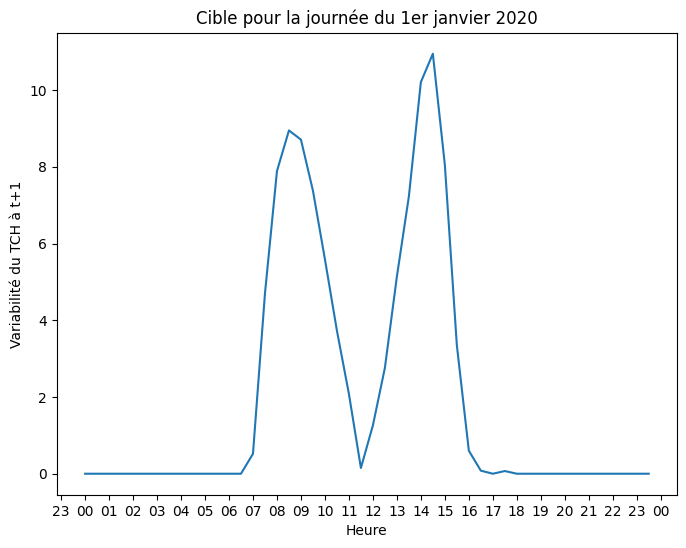

In [31]:
import matplotlib.dates as md

example = df.iloc[2:50]

fig, ax = plt.subplots(figsize=(8,6))

plt.plot(example['datetime_utc'], example['target'])

xloc=md.HourLocator(interval = 1)
ax.xaxis.set_major_locator(xloc)

major_fmt = md.DateFormatter('%H')
ax.xaxis.set_major_formatter(major_fmt)

plt.xlabel('Heure')
plt.ylabel('Variabilité du TCH à t+1')
plt.title('Cible pour la journée du 1er janvier 2020')
plt.show()
